In [3]:
from tensorflow import keras

In [4]:
(x_train,_),(x_test,_) = keras.datasets.fashion_mnist.load_data()
print(x_train.shape)
print(x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(10000, 28, 28)


In [5]:
x_train = x_train.astype('float32')/255.0;
x_test = x_test.astype('float32')/255.0;

In [6]:
encoder = keras.models.Sequential([
    keras.layers.Reshape((28,28,1),input_shape=(28,28)),
    keras.layers.Conv2D(32,(3,3),padding='same',activation='relu'),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Conv2D(64,(3,3),padding='same',activation='relu'),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Conv2D(128,(3,3),padding='same',activation='relu'),
    keras.layers.MaxPooling2D(2,2),
    # keras.layers.Flatten()
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
encoder.predict(x_test[1].reshape(1,28,28)).shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


(1, 3, 3, 128)

In [8]:
decoder = keras.models.Sequential([
    # keras.layers.Reshape((1,1,128),input_shape=(128,)),
    keras.layers.Conv2DTranspose(64,(3,3),activation='relu',strides=2,padding='valid',input_shape=[3,3,128]),
    keras.layers.Conv2DTranspose(32,(3,3),activation='relu',strides=2,padding='same'),
    keras.layers.Conv2DTranspose(1,(3,3),activation='sigmoid',strides=2,padding='same'),
    keras.layers.Reshape([28,28])

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv_transpose.py:94: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


In [9]:
stacked_autoencoder=keras.models.Sequential([encoder,decoder])


In [10]:
stacked_autoencoder.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
stacked_autoencoder.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 3, 3, 128)      │        92,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 28, 28)         │        92,545 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,217 (723.50 KB)

 Trainable params: 185,217 (723.50 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from sklearn.model_selection import train_test_split
x_train_splits,x_val = train_test_split(x_train , random_state=101 ,test_size=0.2)
history = stacked_autoencoder.fit(x_train_splits,x_train_splits ,epochs = 10 , batch_size = 400 , validation_data=(x_val,x_val))
stacked_autoencoder.evaluate(x_test,x_test)

Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.2470 - loss: 0.2678 - val_accuracy: 0.2524 - val_loss: 0.2702
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2509 - loss: 0.2673 - val_accuracy: 0.2512 - val_loss: 0.2680
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2536 - loss: 0.2675 - val_accuracy: 0.2573 - val_loss: 0.2676
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2571 - loss: 0.2665 - val_accuracy: 0.2577 - val_loss: 0.2665
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2586 - loss: 0.2657 - val_accuracy: 0.2600 - val_loss: 0.2659
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.2624 - loss: 0.2645 - val_accuracy: 0.2628 - val_loss: 0.2654
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.2671 - loss: 0.2643 - val_accuracy: 0.2657 - val_loss: 0.2649
Epoch 8/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2700 - loss: 0.2632 - val_accu

[0.26493409276008606, 0.2824535369873047]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


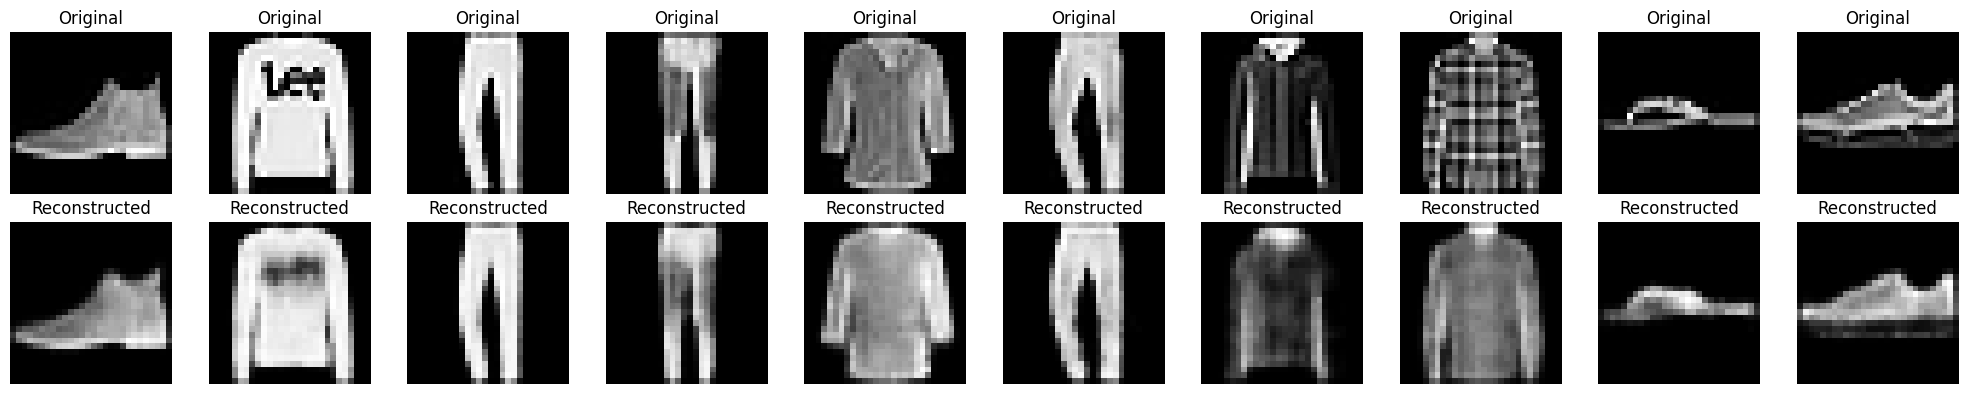

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 4))

for i in range(10):
    # 1. ORIGINAL IMAGES
    ax = plt.subplot(2, 10, i + 1)
    # MNIST is grayscale, so we reshape to (28, 28) and use 'gray' colormap
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    ax.axis('off')

    # 2. RECONSTRUCTED IMAGES
    ax = plt.subplot(2, 10, i + 1 + 10) # Position in the second row
    # Predict needs (1, 28, 28, 1) or (1, 784) depending on your model type
    # Let's assume a flattened input for a Stacked Autoencoder:
    input_img = x_test[i].reshape(1,28,28)
    pred = stacked_autoencoder.predict(input_img)

    plt.imshow(pred.reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    ax.axis('off')

plt.tight_layout()
plt.show()